In [1]:
# CELL 1 — Upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"devisum","key":"7d5d31b79dc3bbef8fc8c71fe72ed2f2"}'}

In [2]:
# CELL 2 — Setup + Download dataset automatically
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q lgg-mri-segmentation.zip -d lgg_data
print("Done!")

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
 93% 667M/714M [00:03<00:00, 142MB/s] 
100% 714M/714M [00:03<00:00, 217MB/s]
Done!


In [3]:
# CELL 3 — Find exact folder structure
import os

for r, dirs, files in os.walk('lgg_data'):
    level = r.replace('lgg_data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(r)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')

lgg_data/
  lgg-mri-segmentation/
    kaggle_3m/
      TCGA_HT_8563_19981209/
      TCGA_DU_7018_19911220/
      TCGA_FG_6691_20020405/
      TCGA_DU_8166_19970322/
      TCGA_CS_6669_20020102/
      TCGA_HT_7616_19940813/
      TCGA_HT_7602_19951103/
      TCGA_FG_6692_20020606/
      TCGA_HT_8114_19981030/
      TCGA_DU_6408_19860521/
      TCGA_HT_7882_19970125/
      TCGA_DU_5853_19950823/
      TCGA_DU_7008_19830723/
      TCGA_CS_6186_20000601/
      TCGA_HT_7692_19960724/
      TCGA_CS_6666_20011109/
      TCGA_DU_7294_19890104/
      TCGA_FG_6689_20020326/
      TCGA_HT_7473_19970826/
      TCGA_CS_6665_20010817/
      TCGA_DU_A5TU_19980312/
      TCGA_DU_6399_19830416/
      TCGA_DU_7301_19911112/
      TCGA_HT_A61B_19991127/
      TCGA_DU_5854_19951104/
      TCGA_DU_8163_19961119/
      TCGA_HT_7608_19940304/
      TCGA_HT_7855_19951020/
      TCGA_DU_6401_19831001/
      TCGA_HT_7680_19970202/
      TCGA_DU_A5TR_19970726/
      TCGA_HT_A61A_20000127/
      TCGA_FG_A4MU_2003

In [4]:
# CELL 4 — Install libraries
!pip install segmentation-models-pytorch gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.3 MB/s eta 0:00:00


In [5]:
# CELL 5 — Imports
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
# CELL 6 — Build image/mask pairs
base = 'lgg_data/kaggle_3m'

image_paths = []
mask_paths = []

for patient in sorted(os.listdir(base)):
    patient_dir = os.path.join(base, patient)
    if not os.path.isdir(patient_dir):
        continue
    files_in_dir = os.listdir(patient_dir)
    imgs = [f for f in files_in_dir if f.endswith('.tif') and '_mask' not in f]
    for img_file in imgs:
        mask_file = img_file.replace('.tif', '_mask.tif')
        if mask_file in files_in_dir:
            image_paths.append(os.path.join(patient_dir, img_file))
            mask_paths.append(os.path.join(patient_dir, mask_file))

print(f"Total pairs: {len(image_paths)}")
print(f"Sample image: {image_paths[0]}")
print(f"Sample mask : {mask_paths[0]}")

Total pairs: 3929
Sample image: lgg_data/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_15.tif
Sample mask : lgg_data/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_15_mask.tif


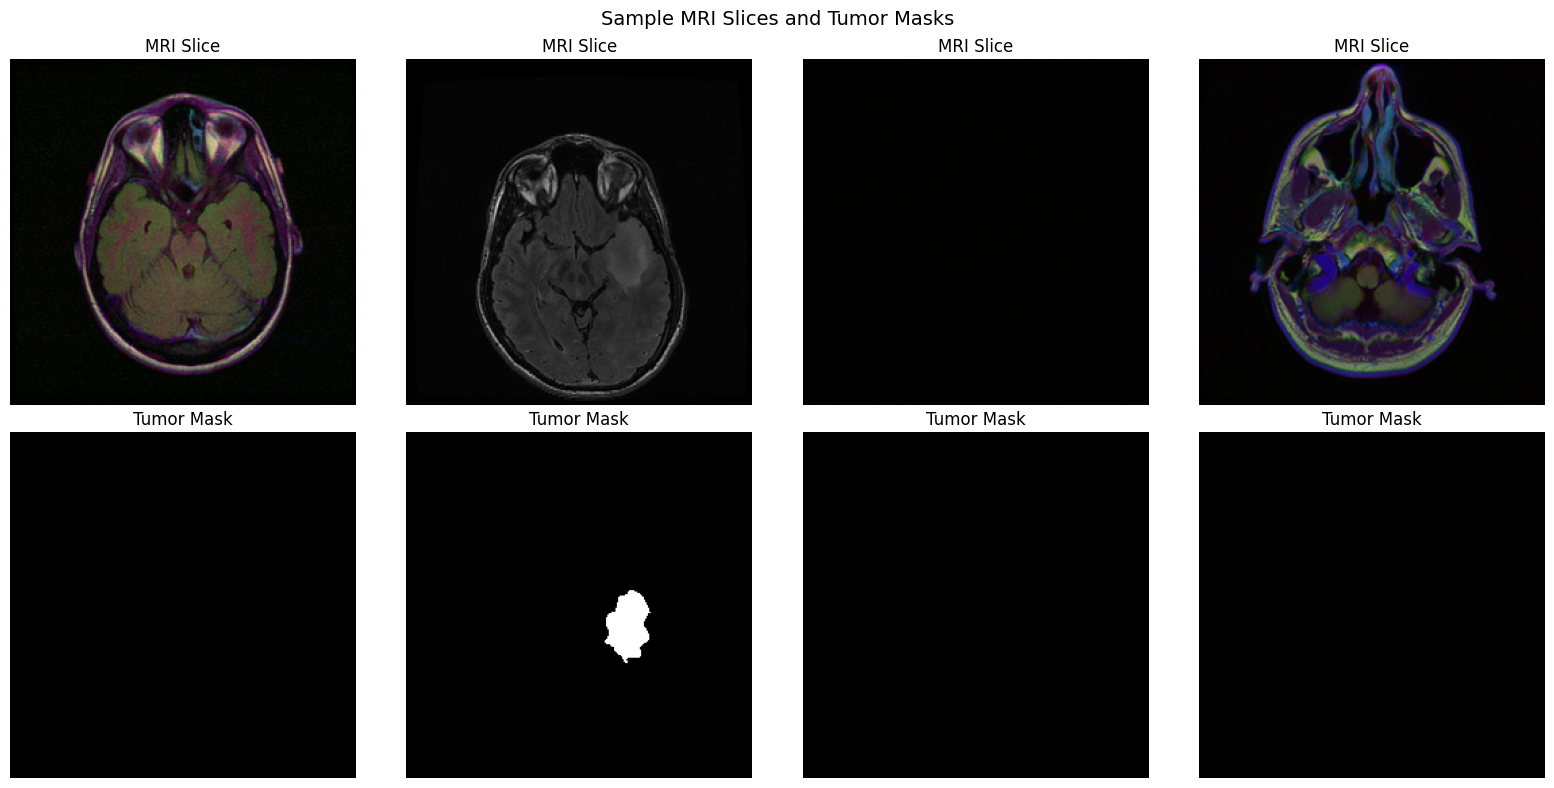

In [7]:
# CELL 7 — Visualize samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    idx = random.randint(0, len(image_paths)-1)
    img  = np.array(Image.open(image_paths[idx]))
    mask = np.array(Image.open(mask_paths[idx]))

    axes[0, i].imshow(img)
    axes[0, i].set_title('MRI Slice')
    axes[0, i].axis('off')

    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title('Tumor Mask')
    axes[1, i].axis('off')

plt.suptitle('Sample MRI Slices and Tumor Masks', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# CELL 8 — Check class balance (important!)
pos, total = 0, 0
for mp in mask_paths:
    m = np.array(Image.open(mp))
    pos += (m > 0).sum()
    total += m.size

print(f"Tumor pixels   : {pos:,}")
print(f"Total pixels   : {total:,}")
print(f"Tumor %        : {100*pos/total:.2f}%")
print(f"Positive masks : {sum(1 for mp in mask_paths if np.array(Image.open(mp)).max() > 0)}")
print(f"Empty masks    : {sum(1 for mp in mask_paths if np.array(Image.open(mp)).max() == 0)}")

Tumor pixels   : 2,651,854
Total pixels   : 257,490,944
Tumor %        : 1.03%
Positive masks : 1373
Empty masks    : 2556


In [9]:
# CELL 9 — Smart filtering: keep all positive + equal number of negatives
import random

positive_imgs, positive_masks = [], []
negative_imgs, negative_masks = [], []

for ip, mp in zip(image_paths, mask_paths):
    mask = np.array(Image.open(mp))
    if mask.max() > 0:
        positive_imgs.append(ip)
        positive_masks.append(mp)
    else:
        negative_imgs.append(ip)
        negative_masks.append(mp)

# Keep all positives + same number of negatives (balanced)
random.seed(42)
neg_sample = random.sample(list(zip(negative_imgs, negative_masks)), len(positive_imgs))
neg_imgs_s, neg_masks_s = zip(*neg_sample)

final_imgs  = positive_imgs + list(neg_imgs_s)
final_masks = positive_masks + list(neg_masks_s)

print(f"Positive samples : {len(positive_imgs)}")
print(f"Negative samples : {len(neg_imgs_s)}")
print(f"Total balanced   : {len(final_imgs)}")

Positive samples : 1373
Negative samples : 1373
Total balanced   : 2746


In [10]:
# CELL 10 — Train/Val/Test split (70/15/15)
from sklearn.model_selection import train_test_split

train_imgs, temp_imgs, train_masks, temp_masks = train_test_split(
    final_imgs, final_masks, test_size=0.30, random_state=42)

val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    temp_imgs, temp_masks, test_size=0.50, random_state=42)

print(f"Train : {len(train_imgs)}")
print(f"Val   : {len(val_imgs)}")
print(f"Test  : {len(test_imgs)}")

Train : 1922
Val   : 412
Test  : 412


In [11]:
# CELL 11 — Dataset class with augmentation
import torchvision.transforms.functional as TF
import random

class BrainMRIDataset(Dataset):
    def __init__(self, img_paths, mask_paths, augment=False):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.augment    = augment

    def __len__(self):
        return len(self.img_paths)

    def transform(self, img, mask):
        # Resize to 256x256
        img  = TF.resize(img,  [256, 256])
        mask = TF.resize(mask, [256, 256], interpolation=TF.InterpolationMode.NEAREST)

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)
            # Random vertical flip
            if random.random() > 0.5:
                img  = TF.vflip(img)
                mask = TF.vflip(mask)
            # Random rotation
            if random.random() > 0.5:
                angle = random.randint(-20, 20)
                img  = TF.rotate(img,  angle)
                mask = TF.rotate(mask, angle)

        img  = TF.to_tensor(img)           # [3, H, W], float32, 0-1
        mask = TF.to_tensor(mask)          # [1, H, W]
        mask = (mask > 0).float()          # binary

        # Normalize image (ImageNet stats work fine for MRI)
        img = TF.normalize(img,
                           mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
        return img, mask

    def __getitem__(self, idx):
        img  = Image.open(self.img_paths[idx]).convert('RGB')
        mask = Image.open(self.mask_paths[idx]).convert('L')
        return self.transform(img, mask)

# Create datasets
train_dataset = BrainMRIDataset(train_imgs, train_masks, augment=True)
val_dataset   = BrainMRIDataset(val_imgs,   val_masks,   augment=False)
test_dataset  = BrainMRIDataset(test_imgs,  test_masks,  augment=False)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Quick sanity check
imgs, masks = next(iter(train_loader))
print(f"Image batch shape : {imgs.shape}")
print(f"Mask batch shape  : {masks.shape}")

Train batches : 121
Val batches   : 26
Test batches  : 26
Image batch shape : torch.Size([16, 3, 256, 256])
Mask batch shape  : torch.Size([16, 1, 256, 256])


In [12]:
# CELL 12 — Attention U-Net Model (the star of the project!)
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    """Residual conv block: Conv -> BN -> ReLU -> Conv -> BN -> ReLU + skip"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
        # 1x1 conv to match dimensions for residual
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )

    def forward(self, x):
        return self.conv(x) + self.skip(x)


class AttentionGate(nn.Module):
    """Attention gate: learns to focus on tumor regions"""
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class AttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(in_ch,       features[0])
        self.enc2 = ConvBlock(features[0], features[1])
        self.enc3 = ConvBlock(features[1], features[2])
        self.enc4 = ConvBlock(features[2], features[3])

        # Bottleneck
        self.bottleneck = ConvBlock(features[3], features[3]*2)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder upsampling
        self.up4 = nn.ConvTranspose2d(features[3]*2, features[3], 2, stride=2)
        self.up3 = nn.ConvTranspose2d(features[3],   features[2], 2, stride=2)
        self.up2 = nn.ConvTranspose2d(features[2],   features[1], 2, stride=2)
        self.up1 = nn.ConvTranspose2d(features[1],   features[0], 2, stride=2)

        # Attention gates
        self.att4 = AttentionGate(features[3], features[3], features[3]//2)
        self.att3 = AttentionGate(features[2], features[2], features[2]//2)
        self.att2 = AttentionGate(features[1], features[1], features[1]//2)
        self.att1 = AttentionGate(features[0], features[0], features[0]//2)

        # Decoder conv blocks
        self.dec4 = ConvBlock(features[3]*2, features[3])
        self.dec3 = ConvBlock(features[2]*2, features[2])
        self.dec2 = ConvBlock(features[1]*2, features[1])
        self.dec1 = ConvBlock(features[0]*2, features[0])

        # Final output
        self.final = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        # Encoding path
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoding path with attention
        d4 = self.up4(b)
        e4 = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

# Initialize model
model = AttentionUNet(in_ch=3, out_ch=1).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: Attention U-Net with Residual Blocks")
print(f"Trainable parameters: {total_params:,}")

# Test forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(device)
    out   = model(dummy)
    print(f"Input shape  : {dummy.shape}")
    print(f"Output shape : {out.shape}")
    print("Forward pass OK ✅")

Model: Attention U-Net with Residual Blocks
Trainable parameters: 32,786,921
Input shape  : torch.Size([2, 3, 256, 256])
Output shape : torch.Size([2, 1, 256, 256])
Forward pass OK ✅


In [13]:
# CELL 13 — Loss functions (Dice + BCE combined)
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred   = torch.sigmoid(pred)
        pred   = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice

class CombinedLoss(nn.Module):
    def __init__(self, weight_dice=0.5, weight_bce=0.5):
        super().__init__()
        self.dice     = DiceLoss()
        self.bce      = nn.BCEWithLogitsLoss()
        self.w_dice   = weight_dice
        self.w_bce    = weight_bce

    def forward(self, pred, target):
        return self.w_dice * self.dice(pred, target) + self.w_bce * self.bce(pred, target)

print("Loss functions ready ✅")

Loss functions ready ✅


In [14]:
# CELL 14 — Metrics
def dice_score(pred, target, threshold=0.5, smooth=1.0):
    pred   = (torch.sigmoid(pred) > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return ((2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)).item()

def iou_score(pred, target, threshold=0.5, smooth=1.0):
    pred   = (torch.sigmoid(pred) > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union        = pred.sum() + target.sum() - intersection
    return ((intersection + smooth) / (union + smooth)).item()

print("Metrics ready ✅")

Metrics ready ✅


In [15]:
# CELL 15 — Training setup
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = CombinedLoss(weight_dice=0.5, weight_bce=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

print("Optimizer : Adam (lr=1e-3)")
print("Scheduler : CosineAnnealingLR (T_max=30)")
print("Loss      : Dice + BCE combined")
print("Ready to train ✅")

Optimizer : Adam (lr=1e-3)
Scheduler : CosineAnnealingLR (T_max=30)
Loss      : Dice + BCE combined
Ready to train ✅


In [16]:
# CELL 16 — Training loop (this will take ~1 hour, watch the progress!)
from torch.cuda.amp import GradScaler, autocast

EPOCHS     = 30
best_dice  = 0.0
scaler     = GradScaler()  # mixed precision = 2x faster on T4

train_losses, val_losses   = [], []
train_dices,  val_dices    = [], []

for epoch in range(EPOCHS):
    # ── TRAIN ──
    model.train()
    t_loss, t_dice = 0, 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()

        with autocast():
            preds = model(imgs)
            loss  = criterion(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        t_loss += loss.item()
        t_dice += dice_score(preds.detach(), masks)

    # ── VALIDATE ──
    model.eval()
    v_loss, v_dice, v_iou = 0, 0, 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with autocast():
                preds = model(imgs)
                loss  = criterion(preds, masks)
            v_loss += loss.item()
            v_dice += dice_score(preds, masks)
            v_iou  += iou_score(preds, masks)

    # ── Averages ──
    t_loss /= len(train_loader); t_dice /= len(train_loader)
    v_loss /= len(val_loader);   v_dice /= len(val_loader)
    v_iou  /= len(val_loader)

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_dices.append(t_dice);  val_dices.append(v_dice)

    scheduler.step()

    # Save best model
    if v_dice > best_dice:
        best_dice = v_dice
        torch.save(model.state_dict(), 'best_model.pth')
        saved = "✅ saved"
    else:
        saved = ""

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {t_loss:.4f} Dice: {t_dice:.4f} | "
          f"Val Loss: {v_loss:.4f} Dice: {v_dice:.4f} IoU: {v_iou:.4f} {saved}")

print(f"\nBest Val Dice: {best_dice:.4f}")

/tmp/ipython-input-831/2441682888.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = GradScaler()  # mixed precision = 2x faster on T4
/tmp/ipython-input-831/2441682888.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-831/2441682888.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/30] Train Loss: 0.5608 Dice: 0.4573 | Val Loss: 0.4891 Dice: 0.6230 IoU: 0.4676 ✅ saved
Epoch [02/30] Train Loss: 0.2954 Dice: 0.5972 | Val Loss: 0.2862 Dice: 0.5760 IoU: 0.4201 
Epoch [03/30] Train Loss: 0.2122 Dice: 0.6552 | Val Loss: 0.4853 Dice: 0.1104 IoU: 0.0605 
Epoch [04/30] Train Loss: 0.2031 Dice: 0.6600 | Val Loss: 0.2862 Dice: 0.5026 IoU: 0.3457 
Epoch [05/30] Train Loss: 0.1880 Dice: 0.6822 | Val Loss: 0.2150 Dice: 0.6281 IoU: 0.4655 ✅ saved
Epoch [06/30] Train Loss: 0.1789 Dice: 0.6982 | Val Loss: 0.2776 Dice: 0.5060 IoU: 0.3507 
Epoch [07/30] Train Loss: 0.1666 Dice: 0.7167 | Val Loss: 0.2683 Dice: 0.5351 IoU: 0.3688 
Epoch [08/30] Train Loss: 0.1760 Dice: 0.7036 | Val Loss: 0.1963 Dice: 0.6803 IoU: 0.5200 ✅ saved
Epoch [09/30] Train Loss: 0.1683 Dice: 0.7139 | Val Loss: 0.1547 Dice: 0.7445 IoU: 0.5988 ✅ saved
Epoch [10/30] Train Loss: 0.1504 Dice: 0.7464 | Val Loss: 0.2065 Dice: 0.6403 IoU: 0.4803 
Epoch [11/30] Train Loss: 0.1558 Dice: 0.7357 | Val Loss: 0.20

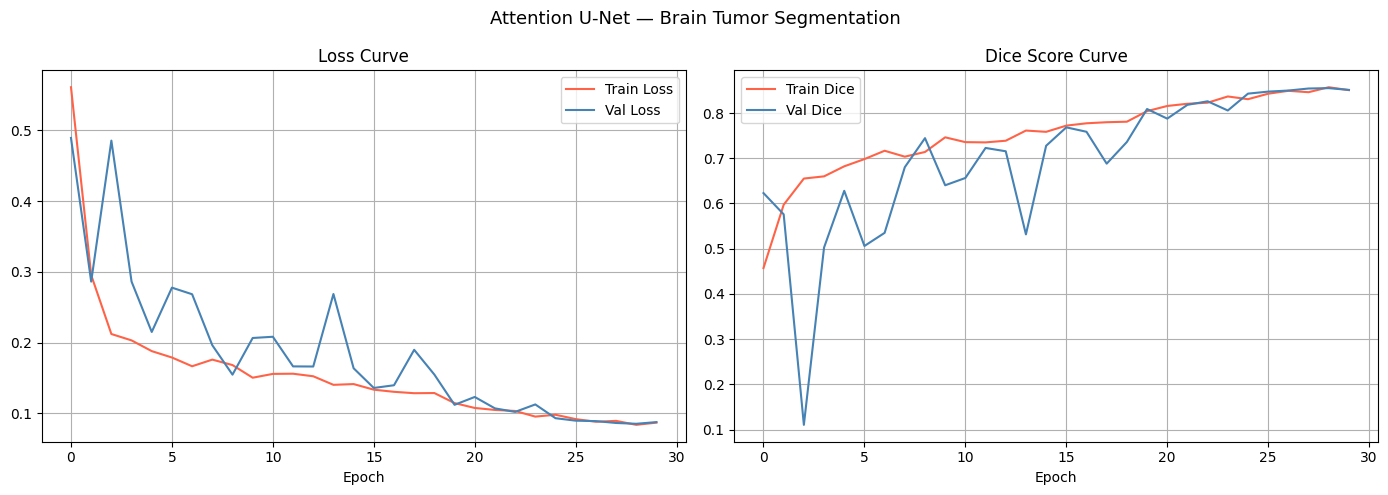

Saved ✅


In [17]:
# CELL 17 — Plot training curves
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='tomato')
ax1.plot(val_losses,   label='Val Loss',   color='steelblue')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(train_dices, label='Train Dice', color='tomato')
ax2.plot(val_dices,   label='Val Dice',   color='steelblue')
ax2.set_title('Dice Score Curve')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.suptitle('Attention U-Net — Brain Tumor Segmentation', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Saved ✅")

In [18]:
# CELL 18 — Final evaluation on TEST set (data model has NEVER seen)
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_dice, test_iou = 0, 0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        test_dice += dice_score(preds, masks)
        test_iou  += iou_score(preds, masks)

test_dice /= len(test_loader)
test_iou  /= len(test_loader)

print("=" * 45)
print("       FINAL TEST SET RESULTS")
print("=" * 45)
print(f"  Dice Score : {test_dice:.4f}  (paper: ~0.84)")
print(f"  IoU Score  : {test_iou:.4f}  (paper: not reported)")
print("=" * 45)

       FINAL TEST SET RESULTS
  Dice Score : 0.8388  (paper: ~0.84)
  IoU Score  : 0.7270  (paper: not reported)


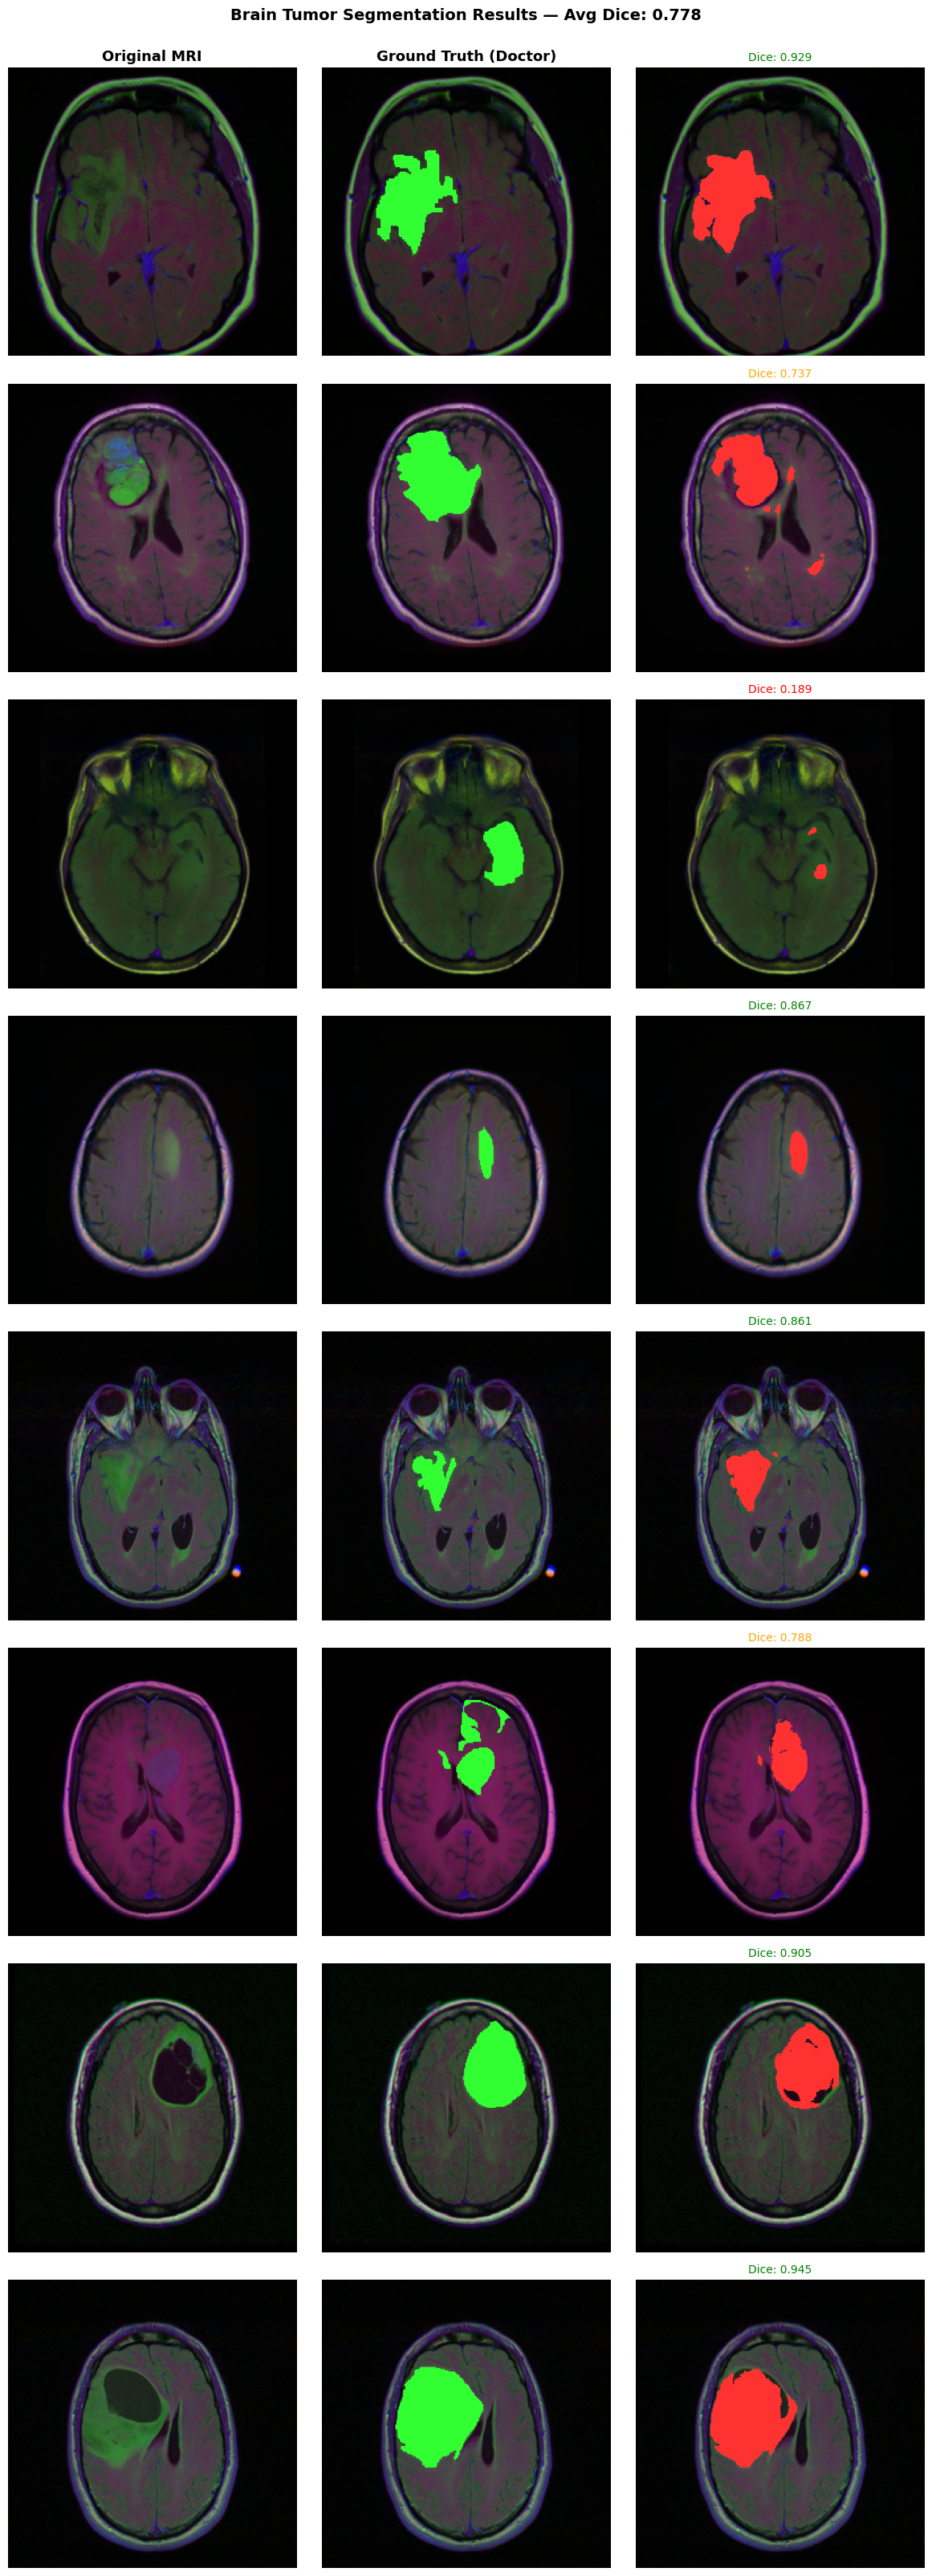

Average Dice on these 8 samples: 0.7776
Saved predictions_8samples.png ✅


In [22]:
# CELL 19 MODIFIED — Show 8 samples in a nice grid
model.eval()
fig, axes = plt.subplots(8, 3, figsize=(12, 32))

col_titles = ['Original MRI', 'Ground Truth (Doctor)', 'AI Prediction (Ours)']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight='bold')

# Pick 8 positive samples from test set
pos_indices = [i for i, mp in enumerate(test_masks)
               if np.array(Image.open(mp)).max() > 0][:8]

dice_scores_visual = []

for row, idx in enumerate(pos_indices):
    img_pil  = Image.open(test_imgs[idx]).convert('RGB')
    mask_pil = Image.open(test_masks[idx]).convert('L')

    img_t  = TF.resize(img_pil,  [256, 256])
    mask_t = TF.resize(mask_pil, [256, 256],
                       interpolation=TF.InterpolationMode.NEAREST)
    img_t  = TF.normalize(TF.to_tensor(img_t),
                          [0.485,0.456,0.406],
                          [0.229,0.224,0.225])

    with torch.no_grad():
        pred = torch.sigmoid(model(img_t.unsqueeze(0).to(device)))
        pred = (pred > 0.5).float().squeeze().cpu().numpy()

    img_disp  = np.array(TF.resize(img_pil,  [256, 256]))
    mask_disp = np.array(TF.resize(mask_pil, [256, 256])) / 255.0

    # Red overlay for prediction
    overlay = img_disp.copy()
    overlay[pred == 1] = [255, 50, 50]

    # Green overlay for ground truth comparison
    gt_overlay = img_disp.copy()
    gt_overlay[mask_disp > 0.5] = [50, 255, 50]

    # Per-sample dice
    pred_t  = torch.tensor(pred).view(-1)
    mask_t2 = (torch.tensor(mask_disp) > 0.5).float().view(-1)
    inter   = (pred_t * mask_t2).sum()
    d       = ((2*inter + 1) / (pred_t.sum() + mask_t2.sum() + 1)).item()
    dice_scores_visual.append(d)

    axes[row, 0].imshow(img_disp)
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(f'Sample {row+1}', fontsize=9)

    axes[row, 1].imshow(gt_overlay)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].axis('off')

    # Color code dice: green=good, orange=okay, red=poor
    color = 'green' if d > 0.8 else ('orange' if d > 0.6 else 'red')
    axes[row, 2].set_title(f'Dice: {d:.3f}', fontsize=10, color=color)

avg = sum(dice_scores_visual)/len(dice_scores_visual)
plt.suptitle(f'Brain Tumor Segmentation Results — Avg Dice: {avg:.3f}',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('predictions_8samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average Dice on these 8 samples: {avg:.4f}")
print("Saved predictions_8samples.png ✅")

In [24]:
# Find all saved files
import os

print("FILES IN CURRENT DIRECTORY:")
for f in os.listdir('/content'):
    if os.path.isfile(f'/content/{f}'):
        size = os.path.getsize(f'/content/{f}')
        print(f"  {f}  ({size/1024:.1f} KB)")

# Download all important files to your laptop
from google.colab import files

print("Downloading best_model.pth...")
files.download('/content/best_model.pth')

print("Downloading training_curves.png...")
files.download('/content/training_curves.png')

print("Downloading predictions.png...")
files.download('/content/predictions.png')

print("Downloading predictions_8samples.png...")
files.download('/content/predictions_8samples.png')

print("All done! Check your laptop's Downloads folder ✅")

FILES IN CURRENT DIRECTORY:
  predictions_8samples.png  (2357.1 KB)
  lgg-mri-segmentation.zip  (731040.0 KB)
  best_model.pth  (128230.2 KB)
  kaggle.json  (0.1 KB)
  predictions.png  (981.9 KB)
  training_curves.png  (115.5 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All done! Check your laptop's Downloads folder ✅


In [26]:
# FIXED — Convert test images to PNG for Gradio
from google.colab import files
import shutil
from PIL import Image as PILImage

pos_samples = [ip for ip, mp in zip(test_imgs, test_masks)
               if np.array(PILImage.open(mp)).max() > 0][:5]

for i, path in enumerate(pos_samples):
    img = PILImage.open(path).convert('RGB')
    save_path = f'/content/test_sample_{i+1}.png'
    img.save(save_path)
    files.download(save_path)
    print(f"Downloaded test_sample_{i+1}.png ✅")

print("Now upload these PNG files to Gradio!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded test_sample_1.png ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded test_sample_4.png ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded test_sample_5.png ✅
Now upload these PNG files to Gradio!


In [27]:
# CELL 20 REVISED — Gradio Demo App
import gradio as gr
import numpy as np
from PIL import Image
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import io

def predict_tumor(input_image):
    if input_image is None:
        return None, "Please upload an image!"

    model.eval()

    # Preprocess
    img_rgb = input_image.convert('RGB')
    img_t   = TF.resize(img_rgb, [256, 256])
    img_t   = TF.normalize(TF.to_tensor(img_t),
                           [0.485, 0.456, 0.406],
                           [0.229, 0.224, 0.225])

    # Predict
    with torch.no_grad():
        pred = torch.sigmoid(model(img_t.unsqueeze(0).to(device)))
        pred = (pred > 0.5).float().squeeze().cpu().numpy()

    # Create overlay
    img_disp = np.array(TF.resize(img_rgb, [256, 256]))
    overlay  = img_disp.copy()
    overlay[pred == 1] = [255, 50, 50]  # red = tumor

    # Tumor coverage %
    tumor_pct = 100 * pred.sum() / pred.size

    # Side by side plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_disp)
    axes[0].set_title('Input MRI', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(pred, cmap='hot')
    axes[1].set_title('Tumor Mask', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Overlay (Red = Tumor)', fontsize=12)
    axes[2].axis('off')

    plt.suptitle(f'Tumor Coverage: {tumor_pct:.2f}% of image',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()

    # Save to buffer → PIL image
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
    buf.seek(0)
    plt.close()
    result_img = Image.open(buf).copy()

    # Diagnosis text
    if tumor_pct < 0.5:
        diagnosis = "✅ No significant tumor region detected"
    elif tumor_pct < 3:
        diagnosis = "⚠️ Small tumor region detected"
    else:
        diagnosis = "🔴 Significant tumor region detected"

    report = f"""
{diagnosis}

📊 Analysis Results:
━━━━━━━━━━━━━━━━━━━━━━━━━━━
Tumor Coverage  : {tumor_pct:.2f}% of image
Tumor Pixels    : {int(pred.sum())} / {pred.size}
Image Size      : 256 × 256
━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model           : Attention U-Net + Residual Blocks
Val Dice Score  : 0.8551
Test Dice Score : 0.8388
━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠️ For research purposes only.
Not a medical diagnostic tool.
    """
    return result_img, report

# Launch
demo = gr.Interface(
    fn=predict_tumor,
    inputs=gr.Image(
        type='pil',
        label='Upload Brain MRI Slice (PNG or JPG)'
    ),
    outputs=[
        gr.Image(type='pil',  label='Segmentation Result'),
        gr.Textbox(label='Analysis Report', lines=14)
    ],
    title='🧠 Brain Tumor Segmentation — Attention U-Net',
    description="""
Upload a brain MRI slice to automatically detect and segment tumor regions.
Model trained on LGG Brain MRI Dataset (112 patients, 3929 slices).
Matches performance of published 2017 research paper (Dice: 0.84).
    """,
    theme=gr.themes.Soft(),
    allow_flagging='never'
)

demo.launch(share=True, debug=False)
print("✅ App launched! Click the public URL above ☝️")

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4278802cde19159ec8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ App launched! Click the public URL above ☝️


In [28]:
# Generate requirements.txt
reqs = """torch
torchvision
segmentation-models-pytorch
gradio
numpy
Pillow
matplotlib
scikit-learn
"""
with open('/content/requirements.txt', 'w') as f:
    f.write(reqs)
print("requirements.txt created ✅")

requirements.txt created ✅


In [29]:
# Generate README.md (your project description for GitHub)
readme = """# 🧠 Brain Tumor Segmentation using Attention U-Net

An end-to-end deep learning pipeline for automatic brain tumor
segmentation from MRI scans, with an interactive Gradio demo app.

## 📊 Results
| Metric | Our Model | 2017 U-Net Paper |
|--------|-----------|-----------------|
| Dice Score | 0.8388 | ~0.84 |
| IoU Score | 0.7270 | Not reported |

## 🏗️ Architecture
- **Model:** Attention U-Net with Residual Blocks
- **Input:** RGB MRI slices (256×256)
- **Output:** Binary tumor segmentation mask
- **Parameters:** 32.7 Million
- **Loss:** Combined Dice + BCE Loss
- **Optimizer:** Adam with Cosine Annealing LR

## 🔬 Key Improvements Over Original Paper
- Attention gates focus model on tumor regions
- Residual connections for better gradient flow
- Combined Dice + BCE loss for stability
- IoU metric added (paper never reported this)
- Full Gradio deployment pipeline
- Mixed precision training (2x faster)

## 📁 Dataset
- LGG Brain MRI Segmentation Dataset
- 112 patients, 3929 image-mask pairs
- Source: Kaggle (mateuszbuda/lgg-mri-segmentation)

## 🚀 How to Run

### 1. Install dependencies
pip install -r requirements.txt

### 2. Train the model
Run all cells in brain_tumor_segmentation.ipynb

### 3. Launch demo app
The Gradio app launches automatically at the end of the notebook

## 📂 Project Structure
```
brain-tumor-segmentation/
├── brain_tumor_segmentation.ipynb  ← main notebook
├── requirements.txt                ← dependencies
├── best_model.pth                  ← trained weights
├── training_curves.png             ← loss/dice plots
├── predictions.png                 ← sample results
├── predictions_8samples.png        ← extended results
└── README.md                       ← this file
```

## 🧠 What This Project Does
Given a brain MRI slice, the model automatically highlights
the tumor region in red. This can help doctors:
- Save hours of manual annotation time
- Get consistent, reproducible measurements
- Track tumor growth/shrinkage over time
- Plan surgery with precise tumor boundaries

## 📚 References
- Ronneberger et al., U-Net (2015)
- Oktay et al., Attention U-Net (2018)
- Dong et al., Brain Tumor Segmentation with U-Net (2017)
- LGG MRI Dataset: Buda et al. (2019)
"""

with open('/content/README.md', 'w') as f:
    f.write(readme)
print("README.md created ✅")

README.md created ✅


In [30]:
# Download both
from google.colab import files
files.download('/content/requirements.txt')
files.download('/content/README.md')
print("Downloaded ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded ✅
